In [95]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [96]:
# load data
df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')

print(df_train.head())
print(df_train.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [97]:
# 基本统计描述
print("训练集大小:", df_train.shape)
print("测试集大小:", df_test.shape)
print()
print("缺失值统计（训练集）:")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print()
print("缺失值统计（测试集）:")
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])
print()
print(df_train.describe())

训练集大小: (891, 12)
测试集大小: (418, 11)

缺失值统计（训练集）:
Age         177
Cabin       687
Embarked      2
dtype: int64

缺失值统计（测试集）:
Age       86
Fare       1
Cabin    327
dtype: int64

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%

C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\880110379.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df_train, palette=['#E85C4C', '#4C9BE8'], ax=axes[1])


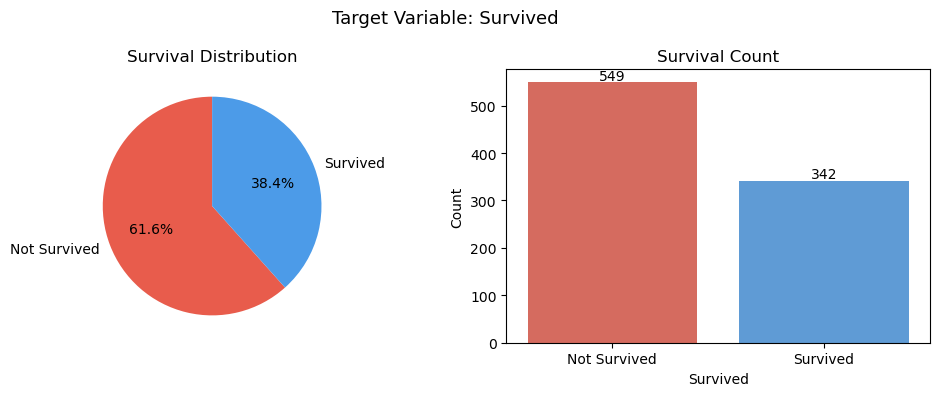

In [98]:
# EDA - 目标变量分布
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 饼状图
survival_counts = df_train['Survived'].value_counts()
axes[0].pie(
    survival_counts,
    labels=['Not Survived', 'Survived'],
    autopct='%1.1f%%',
    colors=['#E85C4C', '#4C9BE8'],
    startangle=90
)
axes[0].set_title('Survival Distribution')

# 柱状图
sns.countplot(x='Survived', data=df_train, palette=['#E85C4C', '#4C9BE8'], ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Survived', 'Survived'])
axes[1].set_title('Survival Count')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                     ha='center')

plt.suptitle('Target Variable: Survived', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\2120851793.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate, x=col, y='SurvivalRate', ax=ax, palette='Blues_d')
C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\2120851793.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate, x=col, y='SurvivalRate', ax=ax, palette='Blues_d')
C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\2120851793.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_rate, x=col, y='SurvivalRate', ax=ax, pa

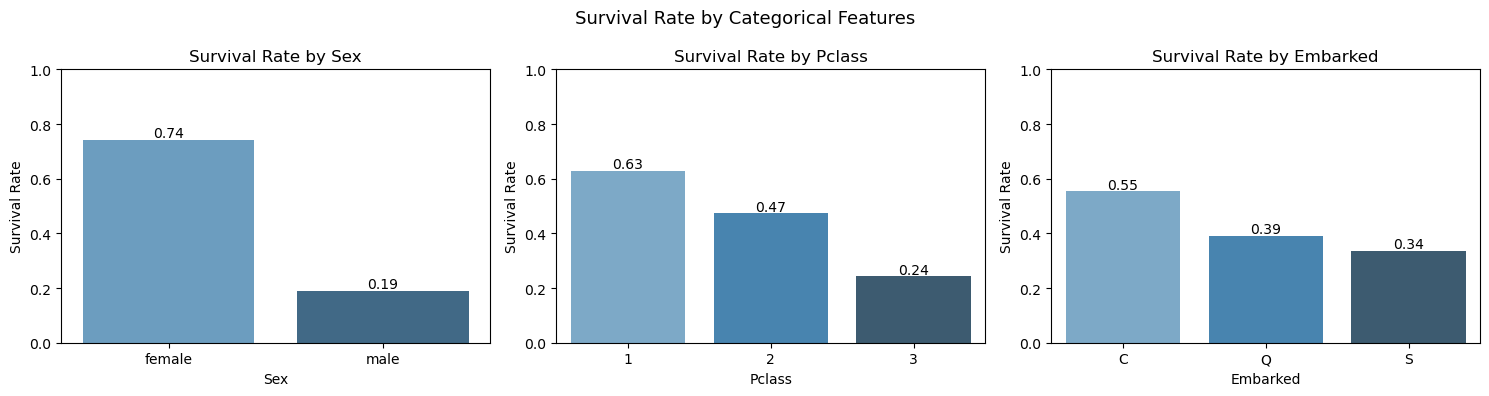

In [99]:
# EDA - 类别特征与生存率的关系
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 柱状图
cat_features_eda = ['Sex', 'Pclass', 'Embarked']
for ax, col in zip(axes, cat_features_eda):
    survival_rate = df_train.groupby(col)['Survived'].mean().reset_index()
    survival_rate.columns = [col, 'SurvivalRate']
    sns.barplot(data=survival_rate, x=col, y='SurvivalRate', ax=ax, palette='Blues_d')
    ax.set_title(f'Survival Rate by {col}')
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                    ha='center', fontsize=10)

plt.suptitle('Survival Rate by Categorical Features', fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\483873310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='Survived', y='Fare',
C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\483873310.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Survived', 'Survived'])


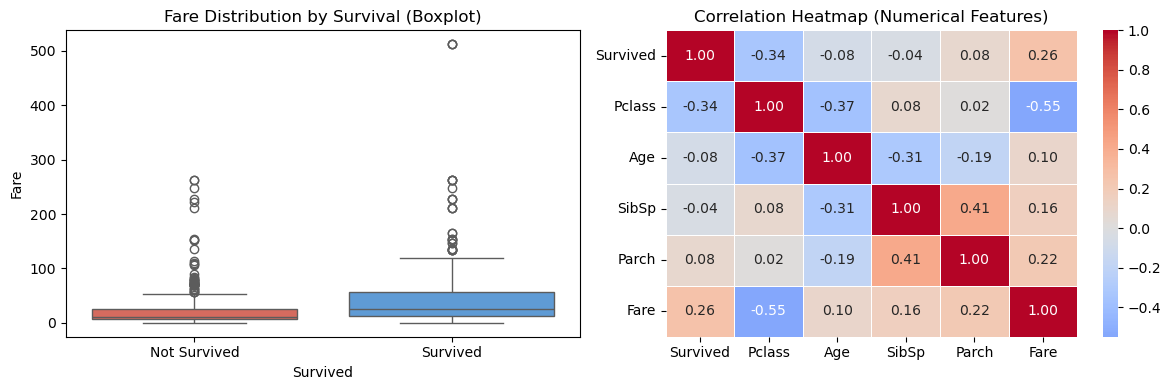

In [100]:
# EDA - 票价分布与相关性
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 箱线图：按生存与否的票价分布
sns.boxplot(data=df_train, x='Survived', y='Fare',
            palette=['#E85C4C', '#4C9BE8'], ax=axes[0])
axes[0].set_xticklabels(['Not Survived', 'Survived'])
axes[0].set_title('Fare Distribution by Survival (Boxplot)')

# 数值特征相关性热力图
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df_train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap (Numerical Features)')

plt.tight_layout()
plt.show()

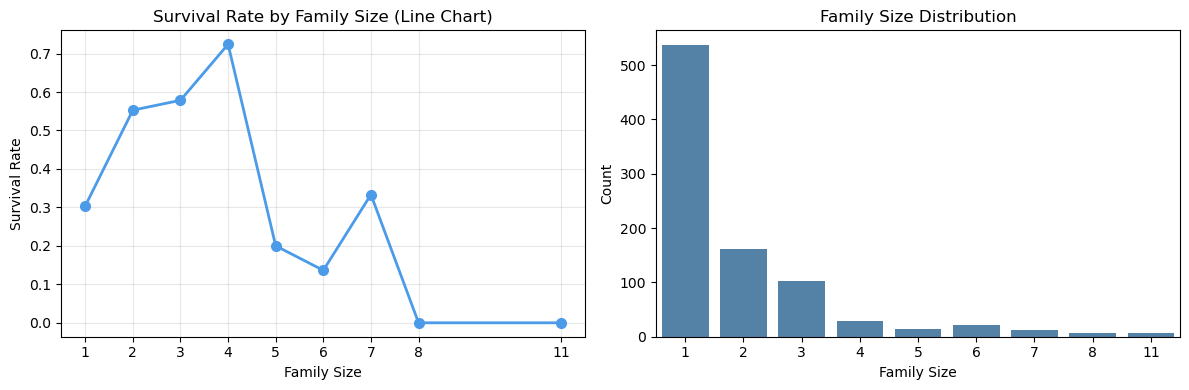

In [101]:
# EDA - 家庭规模与生存率
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1

family_survival = df_train.groupby('FamilySize')['Survived'].mean().reset_index()
family_survival.columns = ['FamilySize', 'SurvivalRate']
family_count = df_train['FamilySize'].value_counts().sort_index().reset_index()
family_count.columns = ['FamilySize', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 折线图：家庭规模 vs 生存率
axes[0].plot(family_survival['FamilySize'], family_survival['SurvivalRate'],
             marker='o', color='#4C9BE8', linewidth=2, markersize=7)
axes[0].set_title('Survival Rate by Family Size (Line Chart)')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticks(family_survival['FamilySize'])
axes[0].grid(True, alpha=0.3)

# 柱状图：家庭规模分布
sns.barplot(data=family_count, x='FamilySize', y='Count',
            color='steelblue', ax=axes[1])
axes[1].set_title('Family Size Distribution')
axes[1].set_xlabel('Family Size')

plt.tight_layout()
plt.show()

In [102]:
# 特征工程
def feature_engineering(df):
    df = df.copy()
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
         'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True)
    return df


df_train_fe = feature_engineering(df_train.drop('Survived', axis=1))
y = df_train['Survived']
df_test_fe = feature_engineering(df_test.copy())
print(df_train_fe.head())
print(df_train_fe.dtypes)

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize Title  \
0       3    male  22.0      1      0   7.2500        S           2    Mr   
1       1  female  38.0      1      0  71.2833        C           2   Mrs   
2       3  female  26.0      0      0   7.9250        S           1  Miss   
3       1  female  35.0      1      0  53.1000        S           2   Mrs   
4       3    male  35.0      0      0   8.0500        S           1    Mr   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  
Pclass          int64
Sex               str
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked          str
FamilySize      int64
Title             str
IsAlone         int64
dtype: object


In [103]:
# 特征分类 & Pipeline
X = df_train_fe.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_features = X_train.select_dtypes(exclude='object').columns.tolist()
cat_features = X_train.select_dtypes(include='object').columns.tolist()
print("数值特征:", num_features)
print("类别特征:", cat_features)

num_pipeline = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('cat_imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num_pipeline', num_pipeline, num_features),
    ('cat_pipeline', cat_pipeline, cat_features)
])

数值特征: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
类别特征: ['Sex', 'Embarked', 'Title']


C:\Users\L1111111T\AppData\Local\Temp\ipykernel_15692\4166100576.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include='object').columns.tolist()


In [104]:
# Baseline Model
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('baseline_clf', DummyClassifier(strategy='most_frequent'))
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred))

Baseline Accuracy: 0.6145251396648045
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179



d:\Anaconda20050906\envs\programming2026\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda20050906\envs\programming2026\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Anaconda20050906\envs\programming2026\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [105]:
# Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lr_clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Cross Validation
cv_scores = cross_val_score(lr_pipeline, X, y, cv=5, scoring='accuracy')
print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Logistic Regression Accuracy: 0.8547486033519553
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

Cross Validation Scores: [0.82122905 0.80898876 0.80898876 0.80337079 0.86516854]
Mean CV Accuracy: 0.8215491808423827


In [106]:
# Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dt_clf', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'preprocessor__num_pipeline__num_imputer__strategy': ['mean', 'median'],
    'preprocessor__cat_pipeline__cat_imputer__strategy': ['most_frequent'],
    'dt_clf__criterion': ['gini', 'entropy'],
    'dt_clf__max_depth': [2, 3, 4, 5, 6]
}

grid_search = GridSearchCV(
    estimator=dt_pipeline, param_grid=param_grid, cv=10, scoring='accuracy'
)
grid_search.fit(X_train, y_train)
print("Best Params:", grid_search.best_params_)
print("Mean CV Accuracy:", grid_search.cv_results_['mean_test_score'].mean())

tree_clf_best = grid_search.best_estimator_
y_pred = tree_clf_best.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best Params: {'dt_clf__criterion': 'entropy', 'dt_clf__max_depth': 3, 'preprocessor__cat_pipeline__cat_imputer__strategy': 'most_frequent', 'preprocessor__num_pipeline__num_imputer__strategy': 'mean'}
Mean CV Accuracy: 0.812024647887324
              precision    recall  f1-score   support

           0       0.85      0.88      0.87       110
           1       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

[[97 13]
 [17 52]]


In [107]:
# Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_clf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf_clf__n_estimators': [50, 100, 200],
    'rf_clf__max_depth': [3, 5, 7, None],
    'rf_clf__criterion': ['gini', 'entropy']
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)
print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

rf_best = rf_grid_search.best_estimator_
y_rf_pred = rf_best.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))

Best Random Forest Parameters:
{'rf_clf__criterion': 'gini', 'rf_clf__max_depth': 5, 'rf_clf__n_estimators': 200}
Random Forest Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [108]:
# Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('gb_clf', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'gb_clf__n_estimators': [100, 200],
    'gb_clf__learning_rate': [0.05, 0.1],
    'gb_clf__max_depth': [3, 4, 5]
}

gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)
print("Best Gradient Boosting Parameters:")
print(gb_grid_search.best_params_)

gb_best = gb_grid_search.best_estimator_
y_gb_pred = gb_best.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_gb_pred))
print(classification_report(y_test, y_gb_pred))

Best Gradient Boosting Parameters:
{'gb_clf__learning_rate': 0.05, 'gb_clf__max_depth': 4, 'gb_clf__n_estimators': 100}
Gradient Boosting Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



                 Model  Accuracy
0             Baseline  0.614525
1  Logistic Regression  0.854749
2        Decision Tree  0.832402
3        Random Forest  0.832402
4    Gradient Boosting  0.804469


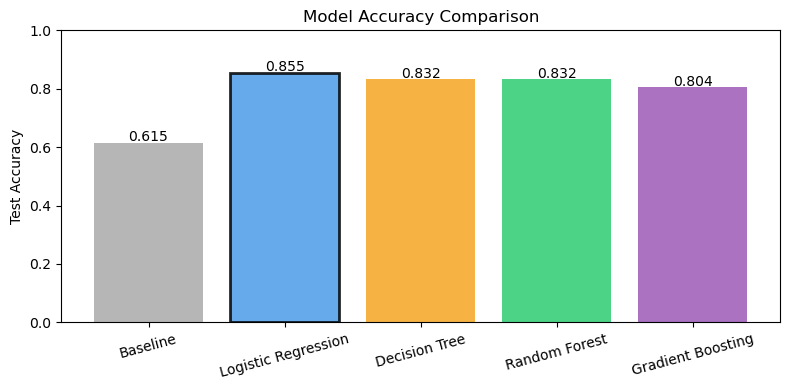

In [109]:
# 模型比较
results = pd.DataFrame({
    'Model': [
        'Baseline',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_rf_pred),
        accuracy_score(y_test, y_gb_pred)
    ]
})
print(results)

# 柱状图对比
plt.figure(figsize=(8, 4))
colors = ['#aaaaaa', '#4C9BE8', '#F5A623', '#2ecc71', '#9b59b6']
bars = plt.bar(results['Model'], results['Accuracy'], color=colors, alpha=0.85)
best_idx = results['Accuracy'].idxmax()
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=10)
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

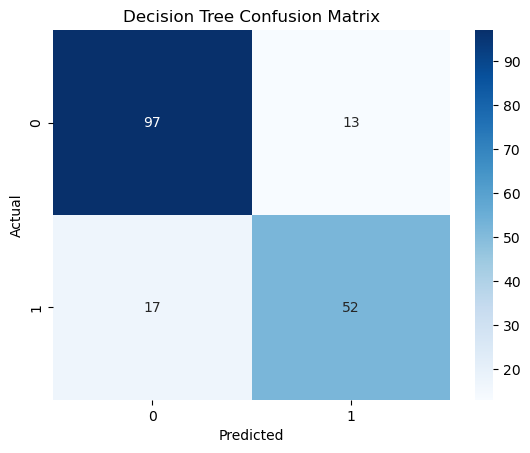

In [110]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

       Feature  Importance
8     Sex_male    0.170968
14    Title_Mr    0.167841
7   Sex_female    0.132650
4         Fare    0.107562
0       Pclass    0.100744
1          Age    0.070366
5   FamilySize    0.055363
13  Title_Miss    0.050918
15   Title_Mrs    0.049259
2        SibSp    0.027463


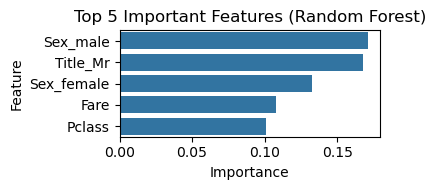

In [111]:
# Feature Importance 特征重要性分析
encoded_cat_features = list(
    rf_best.named_steps['preprocessor']
    .transformers_[1][1]
    .named_steps['onehot']
    .get_feature_names_out(cat_features)
)

feature_names = num_features + encoded_cat_features
importances = rf_best.named_steps['rf_clf'].feature_importances_

feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importance.head(10))

# Feature Importance 可视化
plt.figure(figsize=(4, 2))
sns.barplot(x='Importance', y='Feature', data=feat_importance.head(5))
plt.title('Top 5 Important Features (Random Forest)')
plt.tight_layout()
plt.show()

In [112]:
# 选择最优模型进行最终预测
best_model_name = results.loc[results['Accuracy'].idxmax(), 'Model']
print("Best Model:", best_model_name)

best_model_map = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree':       tree_clf_best,
    'Random Forest':       rf_best,
    'Gradient Boosting':   gb_best
}
final_model = best_model_map.get(best_model_name, rf_best)

X_submit = df_test_fe[X_train.columns]
y_hat = final_model.predict(X_submit)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': y_hat
})

submission.to_csv('submission_titanic.csv', index=False)
print("submission_titanic.csv saved.")
print(submission.head())

Best Model: Logistic Regression
submission_titanic.csv saved.
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
